
##### Libraries call
##### ****************

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt


##### Read data
##### ************

In [17]:
normal_df = pd.read_csv('ptbdb_normal.csv')
abnormal_df = pd.read_csv('ptbdb_abnormal.csv')

# read normal signal without the last column
normal_signal = normal_df.iloc[:, :-1].values
# read abnormal signal without the last column
abnormal_signal = abnormal_df.iloc[:, :-1].values

##### Show only the first row of the normal signal
##### ************************************************

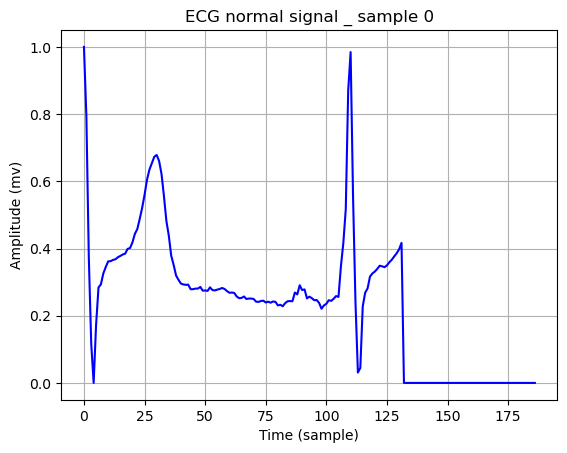

In [18]:
plt.Figure(figsize=(8, 8))
plt.plot(normal_signal[0, :], color='blue')
plt.title('ECG normal signal _ sample 0')
plt.xlabel('Time (sample)')
plt.ylabel('Amplitude (mv)')
plt.grid(True)
plt.show()


##### Show two consecutive rows of the normal signal
##### **************************************************

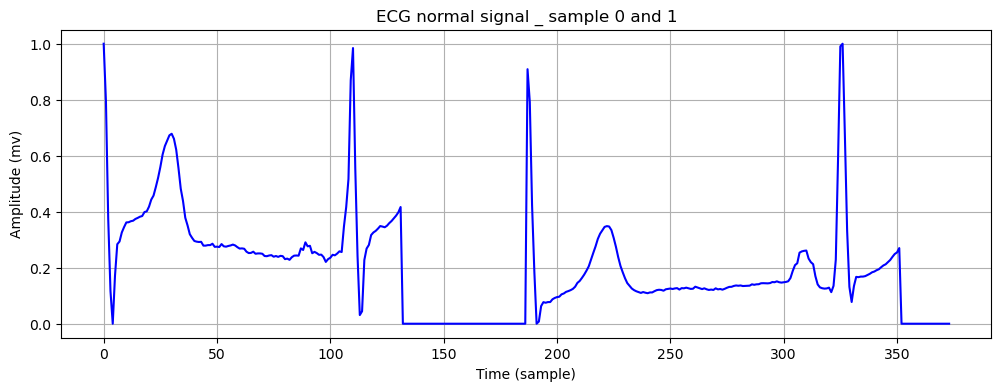

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(normal_signal[0:2].flatten(), color='blue')
plt.title('ECG normal signal _ sample 0 and 1')
plt.xlabel('Time (sample)')
plt.ylabel('Amplitude (mv)')
plt.grid(True)
plt.show()

##### Show only the first row of the abnormal signal
##### ************************************************

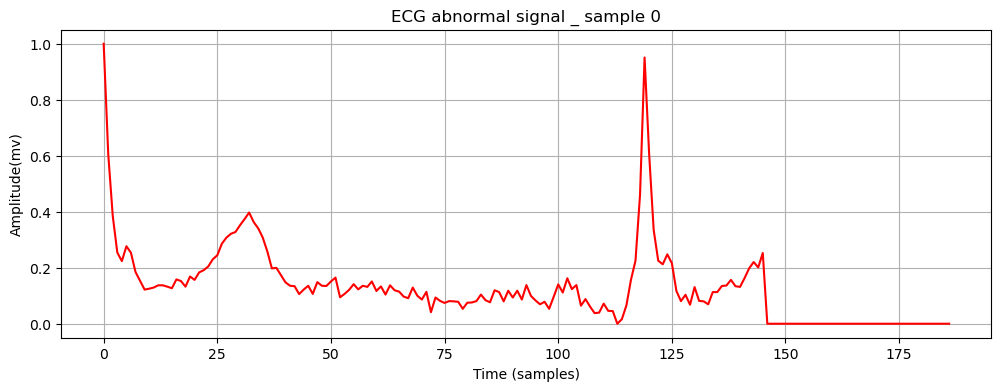

In [20]:
plt.figure(figsize=(12, 4))
plt.plot(abnormal_signal[0, :], color='red')
plt.title('ECG abnormal signal _ sample 0')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude(mv)')
plt.grid(True)
plt.show()

##### Spectral analysis
##### *********************

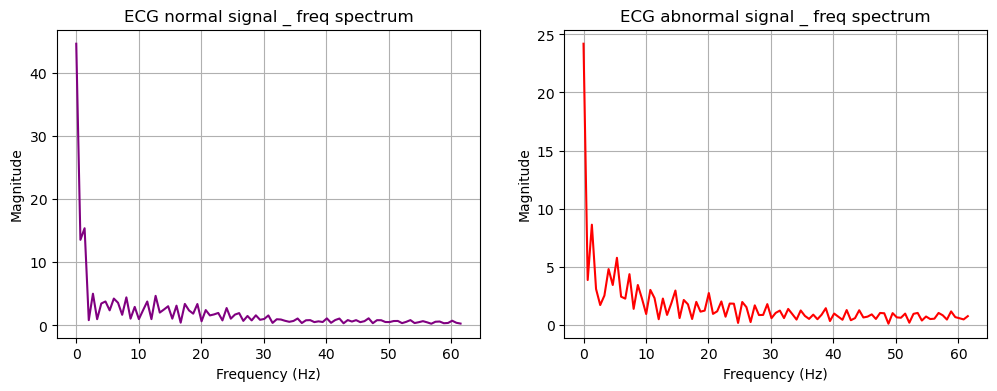

In [21]:
normal_N = normal_signal.shape[1]
abnormal_N = abnormal_signal.shape[1]

normal_spectrum = fft(normal_signal, axis=1)
abnormal_spectrum = fft(abnormal_signal, axis=1)

normal_freq = fftfreq(normal_N, d=1/125)
abnormal_freq = fftfreq(abnormal_N, d=1/125)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(normal_freq[:normal_N//2], np.abs(normal_spectrum[0, :normal_N//2]), color='purple')
axes[0].set_title('ECG normal signal _ freq spectrum')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].grid(True)

axes[1].plot(abnormal_freq[:abnormal_N//2], np.abs(abnormal_spectrum[0, :abnormal_N//2]), color='red')
axes[1].set_title('ECG abnormal signal _ freq spectrum')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude')
axes[1].grid(True)
plt.show()

##### Signal statistics
##### ********************

In [22]:
Nor_mean_val = np.mean(normal_signal.flatten())
Nor_std_val = np.std(normal_signal.flatten())
Nor_max_val = np.max(normal_signal.flatten())
Nor_min_val = np.min(normal_signal.flatten())
Nor_median_val = np.median(normal_signal.flatten())

abNor_mean_val = np.mean(abnormal_signal.flatten())
abNor_std_val = np.std(abnormal_signal.flatten())
abNor_max_val = np.max(abnormal_signal.flatten())
abNor_min_val = np.min(abnormal_signal.flatten())
abNor_median_val = np.median(abnormal_signal.flatten())

print("########### NORMAL ECG SIGNAL INFO.#############\n")
print("Mean:", Nor_mean_val)
print("Standard Deviation:", Nor_std_val)
print("Max:", Nor_max_val)
print("Min:", Nor_min_val)
print("Median:", Nor_median_val)

print("\n########### ABNORMAL ECG SIGNAL INFO.#############\n")
print("Mean:", abNor_mean_val)
print("Standard Deviation:", abNor_std_val)
print("Max:", abNor_max_val)
print("Min:", abNor_min_val)
print("Median:", abNor_median_val)

########### NORMAL ECG SIGNAL INFO.#############

Mean: 0.1584583763648615
Standard Deviation: 0.18098645541321418
Max: 1.0
Min: 0.0
Median: 0.1159263253211975

########### ABNORMAL ECG SIGNAL INFO.#############

Mean: 0.17983254684290348
Standard Deviation: 0.22781363284799921
Max: 1.0
Min: 0.0
Median: 0.0943695455789566


##### **************************************
##### Storing statistics in a dictionary
##### **************************************

In [23]:
states = {
    'normal': {
        'mean': Nor_mean_val,
        'std': Nor_std_val,
        'max': Nor_max_val,
        'min': Nor_min_val,
        'median': Nor_median_val
    },
    'abnormal': {
        'mean': abNor_mean_val,
        'std': abNor_std_val,
        'max': abNor_max_val,
        'min': abNor_min_val,
        'median': abNor_median_val
    }
}

##### Histogram
##### *************

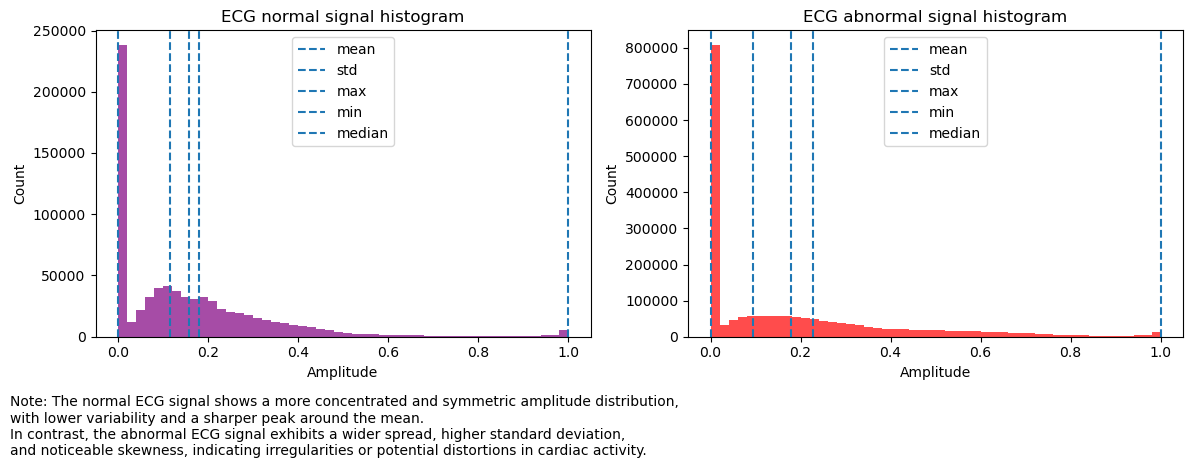

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(normal_signal.flatten(), bins=50, color='purple', alpha=0.7)
axes[0].set_title('ECG normal signal histogram')
axes[0].set_xlabel('Amplitude')
axes[0].set_ylabel('Count')
for key, val in states['normal'].items():
    axes[0].axvline(val, linestyle='--', label=key)
axes[0].legend()

axes[1].hist(abnormal_signal.flatten(), bins=50, color="red", alpha=0.7)
axes[1].set_title('ECG abnormal signal histogram')
axes[1].set_xlabel('Amplitude')
axes[1].set_ylabel('Count')
for key, val in states['abnormal'].items():
    axes[1].axvline(val, linestyle='--', label=key)
axes[1].legend()

plt.tight_layout()


plt.figtext(0.01, -0.15,
            "Note: The normal ECG signal shows a more concentrated and symmetric amplitude distribution,\n"
            "with lower variability and a sharper peak around the mean.\n"
            "In contrast, the abnormal ECG signal exhibits a wider spread, higher standard deviation,\n"
            "and noticeable skewness, indicating irregularities or potential distortions in cardiac activity.",
            ha='left', fontsize=10)

plt.show()


##### Frequency band energy calculation
##### *************************************

In [25]:
nor_band_mask = (normal_freq >= 0.5) & (normal_freq < 40)
nor_band_energy = np.sum(np.abs(normal_spectrum[:, nor_band_mask])**2, axis=1)

abnor_band_mask = (abnormal_freq >= 0.5) & (abnormal_freq < 40)
abnor_band_energy = np.sum(np.abs(abnormal_spectrum[:, abnor_band_mask])**2, axis=1)

##### Show comparison between the two signals
##### ************************************************

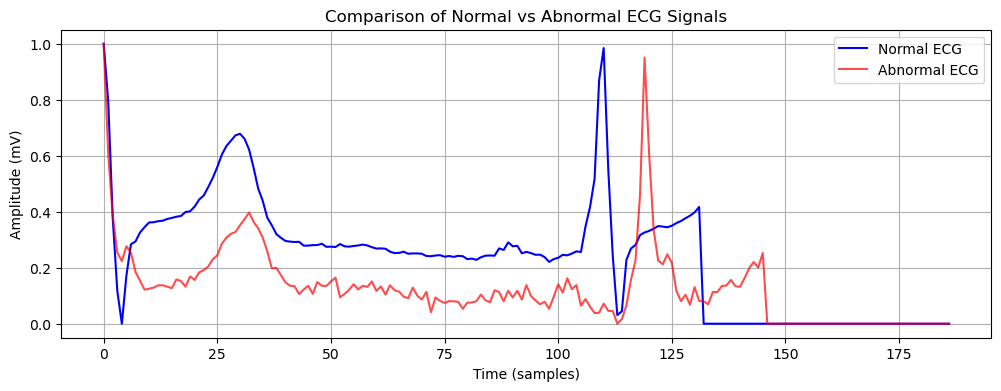

In [27]:
plt.figure(figsize=(12, 4))
plt.plot(normal_signal[0, :], label='Normal ECG', color='blue')
plt.plot(abnormal_signal[0, :], label='Abnormal ECG', color='red', alpha=0.7)
plt.title("Comparison of Normal vs Abnormal ECG Signals")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)
plt.show()

##### Signal filtering
##### ********************

In [28]:
def bandpass_filter(signal, lowcut=0.5, highcut=40, fs=125, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    return filtered

filtered_normal = bandpass_filter(normal_signal)
filtered_abnormal = bandpass_filter(abnormal_signal)

##### Show signal before and after filtering
##### ******************************************

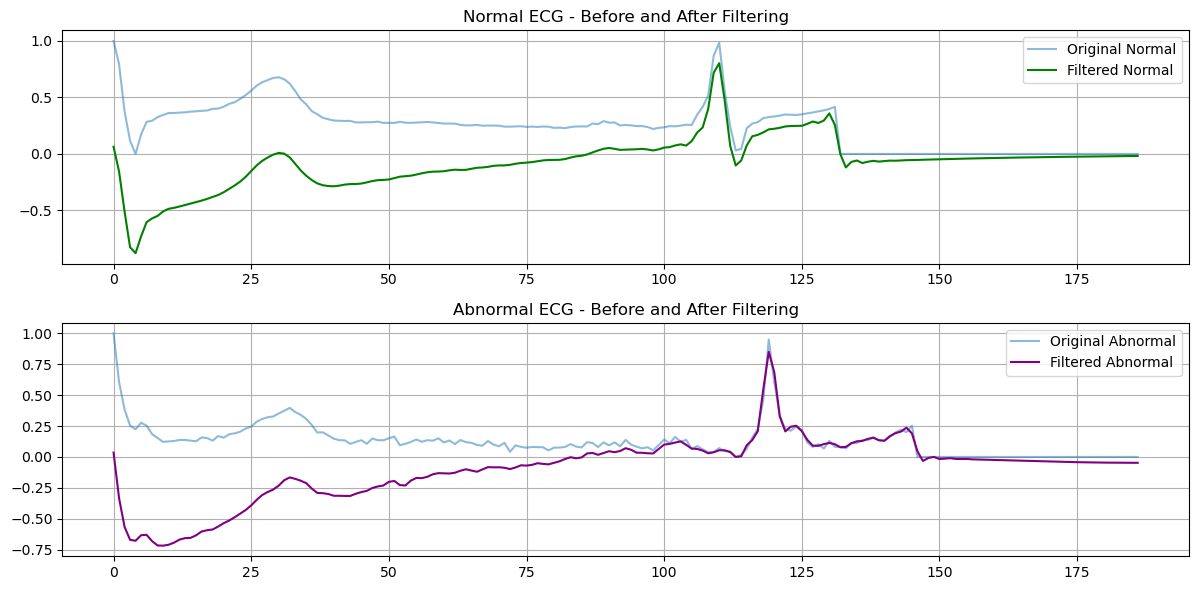

In [29]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(normal_signal[0, :], label='Original Normal', alpha=0.5)
plt.plot(filtered_normal[0, :], label='Filtered Normal', color='green')
plt.title("Normal ECG - Before and After Filtering")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(abnormal_signal[0, :], label='Original Abnormal', alpha=0.5)
plt.plot(filtered_abnormal[0, :], label='Filtered Abnormal', color='purple')
plt.title("Abnormal ECG - Before and After Filtering")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()